In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load the cleaned file we saved in Task 1
df = pd.read_csv('../Task1_EDA/sleep_cleaned.csv')

# Show first 5 rows
df.head()

,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category,sleep_debt_encoded
0,USR-00001,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt,3
1,USR-00002,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt,3
2,USR-00003,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt,3
3,USR-00004,36,Non-Binary,Remote Tech,Intermediate,34,YouTube,52,0,97,49,38.1,6.99,21.6,22.4,1,1.7,Mild Deficit,1
4,USR-00005,23,Female,Healthcare / Shift Worker,Intermediate,27,TikTok / Reels,82,1,0,38,32.3,4.58,24.1,22.8,4,5.3,Moderate Debt,2


In [2]:
# How balanced is our target?
print(df['sleep_debt_encoded'].value_counts())
print("\nMapping:")
print("0 = Optimal Recovery")
print("1 = Mild Deficit")
print("2 = Moderate Debt")
print("3 = Severe Sleep Debt")

sleep_debt_encoded
2    4462
1    2004
0    1387
3     647
Name: count, dtype: int64

Mapping:
0 = Optimal Recovery
1 = Mild Deficit
2 = Moderate Debt
3 = Severe Sleep Debt


In [3]:
# Drop columns we don't need for prediction
# Keep only numeric + encoded categorical features
drop_cols = ['user_id', 'sleep_debt_category', 'sleep_debt_encoded']
X = df.drop(columns=drop_cols)
y = df['sleep_debt_encoded']

# Encode remaining categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

print("\nFeature shape:", X.shape)
X.head()

Categorical columns to encode: ['gender', 'occupation_type', 'chronotype', 'primary_bedtime_app']

Feature shape: (8500, 16)


C:\Users\Hero\AppData\Local\Temp\ipykernel_7768\1718431425.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score
0,29,0,2,0,179,0,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0
1,58,0,4,0,163,5,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0
2,41,0,2,2,100,4,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0
3,36,2,3,0,34,5,52,0,97,49,38.1,6.99,21.6,22.4,1,1.7
4,23,0,2,0,27,4,82,1,0,38,32.3,4.58,24.1,22.8,4,5.3


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (6800, 16)
Test set size: (1700, 16)


In [5]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [6]:
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("F1 Score (weighted):", round(f1_score(y_test, y_pred, average='weighted'), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9994
F1 Score (weighted): 0.9994

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       278
           1       1.00      1.00      1.00       401
           2       1.00      1.00      1.00       892
           3       0.99      1.00      1.00       129

    accuracy                           1.00      1700
   macro avg       1.00      1.00      1.00      1700
weighted avg       1.00      1.00      1.00      1700


Confusion Matrix:
 [[278   0   0   0]
 [  0 401   0   0]
 [  0   0 891   1]
 [  0   0   0 129]]


total_sleep_hours           0.570150
next_day_fatigue_score      0.217704
morning_alarm_snoozes       0.084127
chronotype                  0.036851
sleep_latency_min           0.028365
bedtime_phone_minutes       0.021512
deep_sleep_pct              0.008394
caffeine_post_5pm_mg        0.005679
rem_sleep_pct               0.005602
screen_brightness_pct       0.005524
physical_activity_min       0.004692
age                         0.004475
occupation_type             0.003297
primary_bedtime_app         0.001907
blue_light_filter_active    0.000897
gender                      0.000824
dtype: float64


C:\Users\Hero\AppData\Local\Temp\ipykernel_7768\3177840414.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


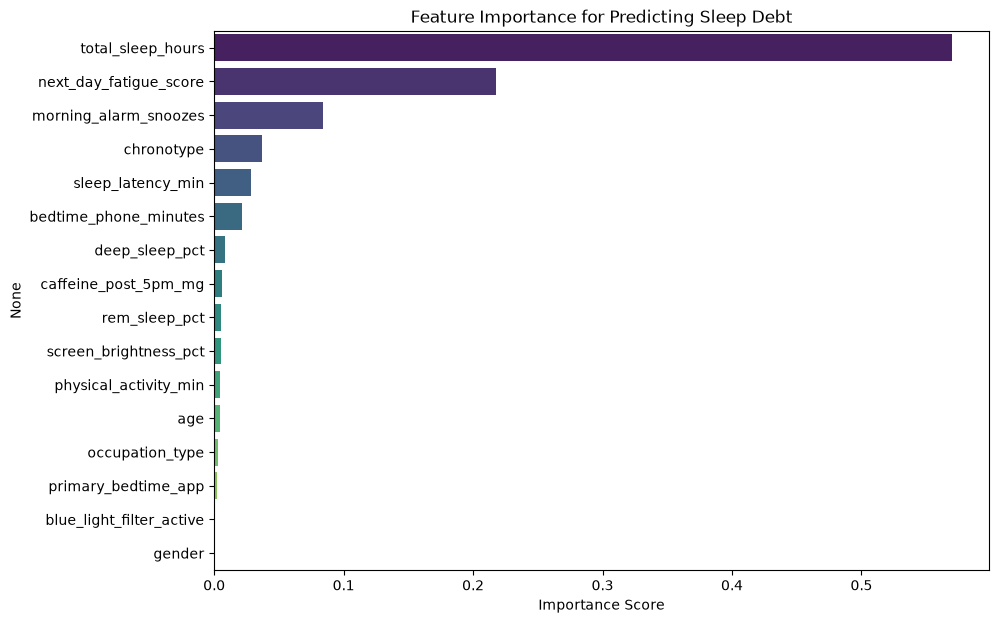

In [7]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
print(importances)

plt.figure(figsize=(10,7))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance for Predicting Sleep Debt')
plt.xlabel('Importance Score')
plt.savefig('feature_importance.png')
plt.show()

In [8]:
import joblib
joblib.dump(model, 'sleep_debt_model.pkl')
print("Model saved as sleep_debt_model.pkl")

Model saved as sleep_debt_model.pkl


SyntaxError: invalid character '–' (U+2013) (2263250330.py, line 9)